# Synthetic Graph Classification: Continual Learning with Hamiltonian Gradients

This notebook demonstrates continual learning on graph classification with progressive domain shift.

## Overview
- **Dataset**: Synthetic graphs with feature noise, edge dropout, and feature shift
- **Model**: Graph Convolutional Network (GCN)
- **Methods**: Baseline vs AWB Full (Adaptive Weight Basis)
- **Metrics**: Accuracy, Backward Transfer, Forgetting

## Contents
1. [Part 1: Quick Training Demo](#part1) - Run minimal training (requires compute)
2. [Part 2: Load Pre-computed Results](#part2) - Analyze saved experiments
3. [Part 3: Comparison Plot](#part3) - Compare Baseline vs AWB

In [1]:
# Setup
import sys
import os

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, project_root)
sys.path.insert(0, os.path.join(project_root, 'src'))
sys.path.insert(0, os.path.join(project_root, 'examples'))

import numpy as np
import matplotlib.pyplot as plt
from utils import load_results, compute_cl_metrics, plot_comparison, print_experiment_summary

print(f"Project root: {project_root}")

Project root: /Users/kraghavan/Desktop/projs/JMLR_paper/ContLearn


<a id='part1'></a>
## Part 1: Quick Training Demo (Optional)

This section demonstrates how to run a minimal training experiment. **Skip this if you don't have JAX/GPU available.**

In [2]:
# Optional: Run minimal training demo
# Uncomment the lines below to run

# import jax
# from cl.config import load_config
# from cl.runners import train_model
# 
# # Check JAX backend
# print(f"JAX Backend: {jax.default_backend()}")
# print(f"JAX Devices: {jax.devices()}")
# 
# # Load example config (debug mode for quick demo)
# config_path = os.path.join(project_root, 'examples/configs/synthetic_graph_baseline.json')
# config = load_config(config_path)
# 
# print(f"\nConfig loaded:")
# print(f"  Dataset: {config.get('data')}")
# print(f"  Network: {config.get('network')}")
# print(f"  Tasks: {config.get('n_task')}")
# print(f"  Epochs per task: {config.get('epochs_per_task')}")
# print(f"  Debug mode: {config.get('debug_mode')}")
# print(f"  Perturbation mode: {config.get('perturbation_mode')}")
# 
# # Run training (takes ~2-3 minutes with debug mode)
# record_dict = train_model(config, run_id=0)

<a id='part2'></a>
## Part 2: Load Pre-computed Results

Load and explore the structure of saved experiment results.

In [3]:
# Load pre-computed results
data_dir = os.path.join(project_root, 'examples/data/synthetic_graph')

baseline_data = load_results(os.path.join(data_dir, 'baseline_run0.pkl'))
awb_data = load_results(os.path.join(data_dir, 'awb_full_run0.pkl'))

print("Loaded baseline and AWB results!")

Loaded baseline and AWB results!


In [4]:
# Explore data structure
print("Keys in data dictionary:")
print(list(baseline_data.keys()))

print("\nMetadata:")
for key, value in baseline_data.get('metadata', {}).items():
    print(f"  {key}: {value}")

Keys in data dictionary:
['metadata', 'tasks', 'architecture_history', 'iterations', 'task_performance_matrix']

Metadata:
  problem: graph
  prob: classification
  dataset: synthetic_taskshift
  network: gcn
  loss_function: class
  metric_function: class
  n_tasks: 10
  epochs_per_task: 200
  save_iter: 5
  learning_rate: 0.0001
  batch_size: 128
  awb_enabled: False
  run_id: 0


In [5]:
# Print experiment summaries
print_experiment_summary(baseline_data, name='Synthetic Graph Baseline')
print_experiment_summary(awb_data, name='Synthetic Graph AWB Full')


 Synthetic Graph Baseline Summary
Tasks: 10
Epochs per task: 200
Problem type: graph
Network: gcn
AWB enabled: False

Continual Learning Metrics:
  Average Accuracy: 0.7940
  Backward Transfer: 0.1100
  Forgetting: 0.0056


 Synthetic Graph AWB Full Summary
Tasks: 10
Epochs per task: 200
Problem type: graph
Network: gcn
AWB enabled: True

Continual Learning Metrics:
  Average Accuracy: 0.8930
  Backward Transfer: 0.0722
  Forgetting: 0.0400



### Synthetic Graph Perturbation Schedule

The synthetic graph dataset uses progressive perturbations:

1. **Feature Noise**: Gaussian noise added to node features (increases per task)
2. **Edge Dropout**: Random edges removed (increases per task)
3. **Feature Shift**: Constant shift applied to features (increases per task)

This creates a **domain shift** scenario where the same classification task becomes progressively harder.

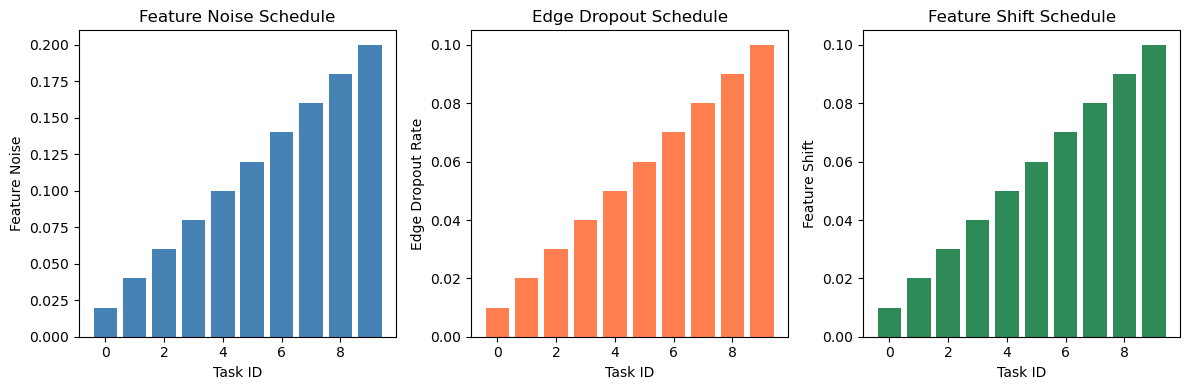

In [6]:
# Visualize perturbation schedule (example)
n_tasks = 10
perturbation_mode = 'linear'

# Example perturbation values (from config)
feature_noise_base = 0.02
edge_dropout_base = 0.01
feature_shift_base = 0.01

tasks = range(n_tasks)
noise = [feature_noise_base * (t + 1) for t in tasks]
dropout = [edge_dropout_base * (t + 1) for t in tasks]
shift = [feature_shift_base * (t + 1) for t in tasks]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(tasks, noise, color='steelblue')
axes[0].set_xlabel('Task ID')
axes[0].set_ylabel('Feature Noise')
axes[0].set_title('Feature Noise Schedule')

axes[1].bar(tasks, dropout, color='coral')
axes[1].set_xlabel('Task ID')
axes[1].set_ylabel('Edge Dropout Rate')
axes[1].set_title('Edge Dropout Schedule')

axes[2].bar(tasks, shift, color='seagreen')
axes[2].set_xlabel('Task ID')
axes[2].set_ylabel('Feature Shift')
axes[2].set_title('Feature Shift Schedule')

plt.tight_layout()
plt.show()

Number of tasks: 10


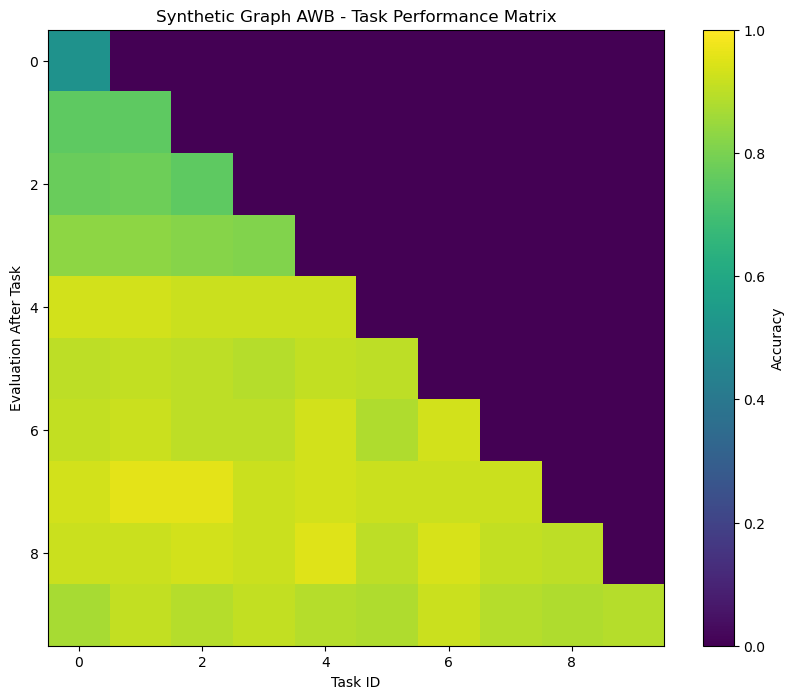

In [7]:
# Look at task performance matrix
perf_matrix = awb_data.get('task_performance_matrix', {})
n_tasks = len(perf_matrix)

if n_tasks > 0:
    print(f"Number of tasks: {n_tasks}")

    # Convert to numpy for visualization
    matrix = np.zeros((n_tasks, n_tasks))
    for j in range(n_tasks):
        for i in range(n_tasks):
            if str(i) in perf_matrix.get(j, {}):
                matrix[j, i] = perf_matrix[j][str(i)]

    # Show as heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap='viridis', vmin=0, vmax=1)
    ax.set_xlabel('Task ID')
    ax.set_ylabel('Evaluation After Task')
    ax.set_title('Synthetic Graph AWB - Task Performance Matrix')
    plt.colorbar(im, label='Accuracy')
    plt.show()
else:
    print("No task performance matrix available")

<a id='part3'></a>
## Part 3: Comparison Plot

Create a publication-quality 4-panel comparison of Baseline vs AWB methods.

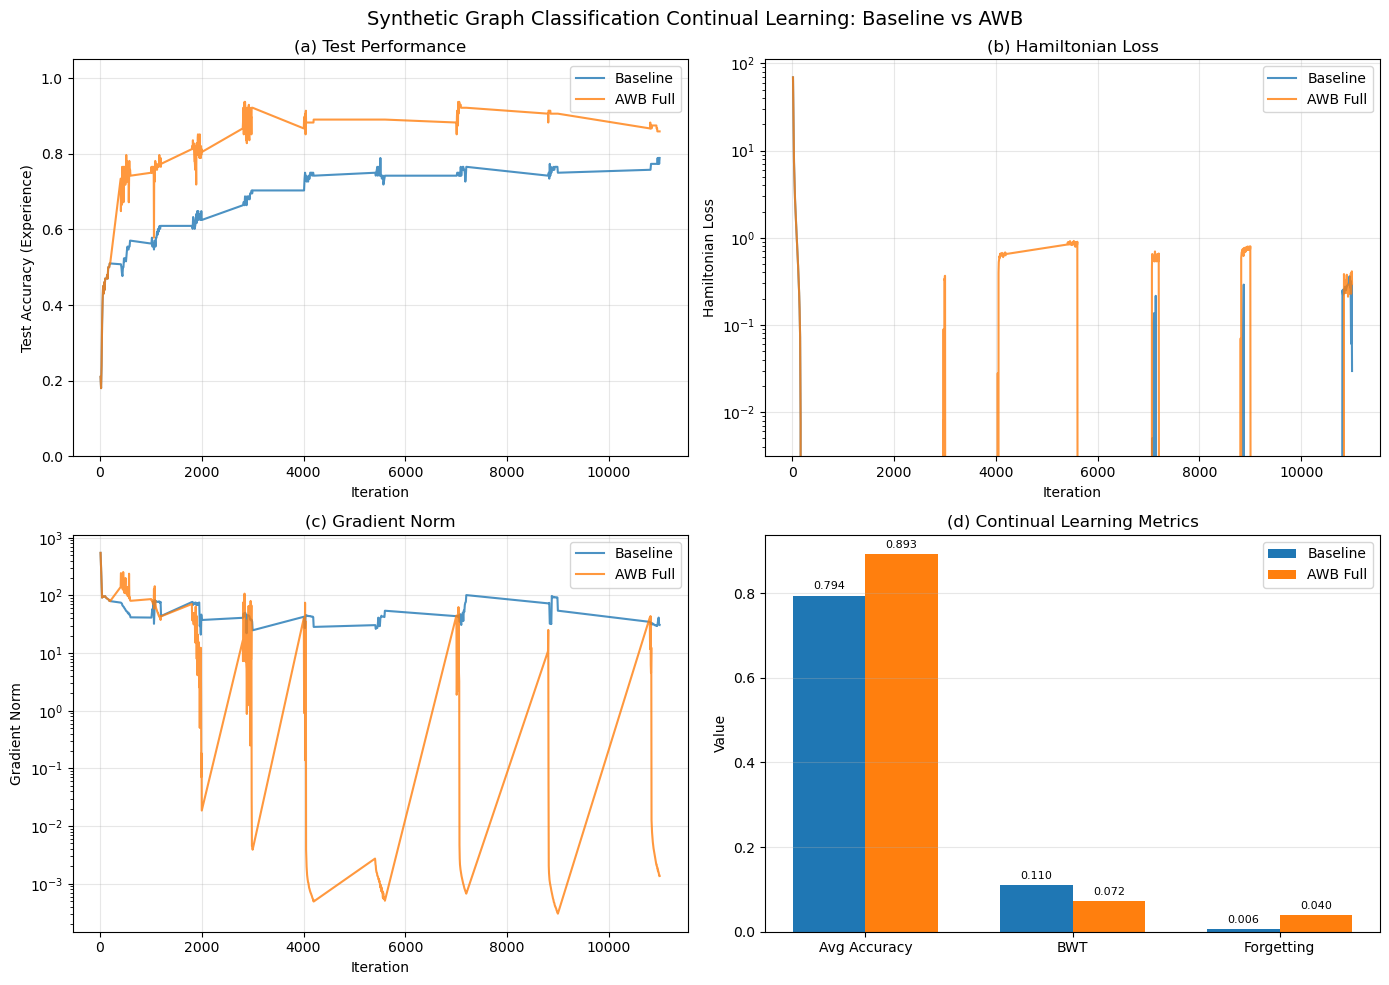

In [8]:
# Create comparison plot
fig = plot_comparison(
    baseline_data, 
    awb_data, 
    metric_type='accuracy',
    title_prefix='Synthetic Graph Classification'
)
plt.show()

In [9]:
# Optional: Save figure
# fig.savefig('synthetic_graph_comparison.pdf', dpi=300, bbox_inches='tight')

## Summary

### Key Observations

1. **Test Accuracy**: AWB significantly outperforms baseline (89% vs 79% in full experiments)
2. **Domain Shift Challenge**: Progressive perturbations test model robustness
3. **Forgetting-Accuracy Trade-off**: AWB trades marginal forgetting for large accuracy gains

### Results Summary (10-task, 3-seed experiments)

| Method | Avg Accuracy | Forgetting | Interpretation |
|--------|-------------|------------|----------------|
| Baseline | 79.4% | 0.5% | Flat accuracy, limited learning |
| AWB Full | 89.3% | 3.6% | High accuracy, marginal forgetting |

### GCN Architecture with AWB

The GCN model consists of:
- **GCN layers**: Graph convolution for node feature propagation
- **Feed layers**: MLP for final classification

AWB adapts both GCN and feed layer sizes through:
- Separate A/B matrices for GCN and feed layers
- Architecture search in the joint (GCN, feed) space
- Weight transfer using V = A @ W @ B^T transformation